c:\Users\Nils\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


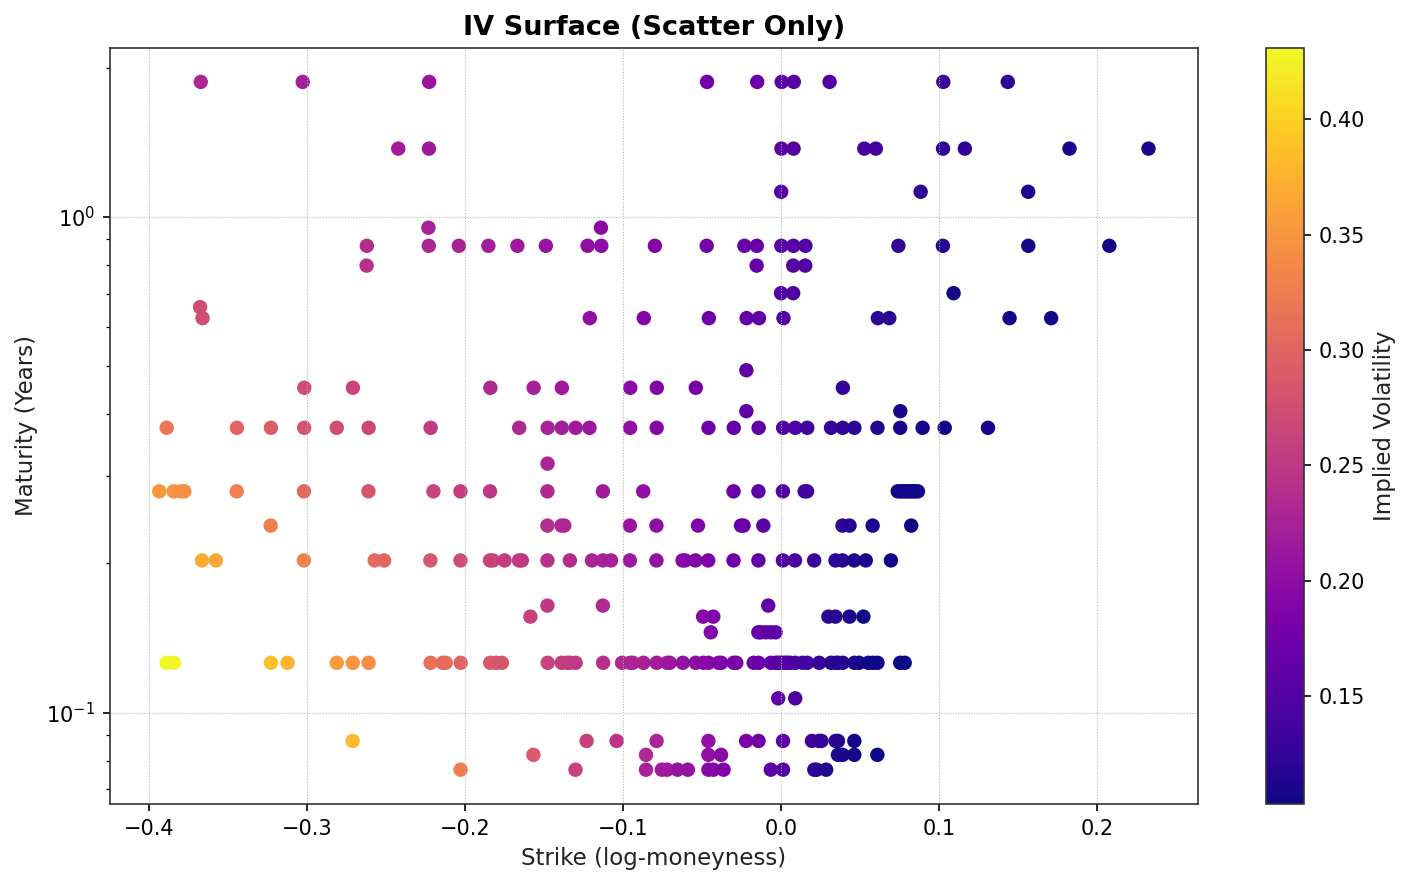

In [1]:
import pandas as pd
import numpy as np
import sys, os
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

vol="rbergomi"

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from generation.utils import plot_iv_surface_scatter, preprocess_and_filter_otm, build_market_surfaces,  plot_param_grid
from models.framework import DeepONet, MLP

df = pd.read_csv("C:/Users/Nils/nn_stochvol_calibrations/real_calibration/data_download.csv")
df = preprocess_and_filter_otm(df)
surfaces = build_market_surfaces(df)
plot_iv_surface_scatter(surfaces[1]["iv_surface"],surfaces[1]["grid"]["strikes"],np.exp(surfaces[1]["grid"]["maturities"]))

In [2]:
model_path=f"C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/{vol}/irregular/deeponet.pth"
x = DeepONet.load(model_path)
deeponet_res = []
for surface in surfaces:
    res = x.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    deeponet_res.append(res)

Loaded DeepONet from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/rbergomi/irregular/deeponet.pth


In [3]:
model_path=f"C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/{vol}/irregular/mlp.pth"
y = MLP.load(model_path)
mlp_res = []
analytic_res = []
for surface in surfaces:
    res = y.calibrate(surface, optimiser="lm", maxiter=500)
    res["date"] = surface["date"]
    mlp_res.append(res)
    
    if vol == "heston":
        res_a = y.calibrate_heston_analytic(surface, optimiser="lm",  maxiter=500)
        res_a["date"] = surface["date"]
        analytic_res.append(res_a)

Loaded MLP from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/rbergomi/irregular/mlp.pth


Saved plot to C:/Users/Nils/nn_stochvol_calibrations/real_calibration/plots/rbergomi\param_grid_plot.png

Average Calibration Runtime (ms):
model
DeepONet              2645.721438
MLP (bil. interp.)     576.905898
Name: runtime_ms, dtype: float64

Average RMSE:
model
DeepONet              0.007334
MLP (bil. interp.)    0.007318
Name: rmse, dtype: float64


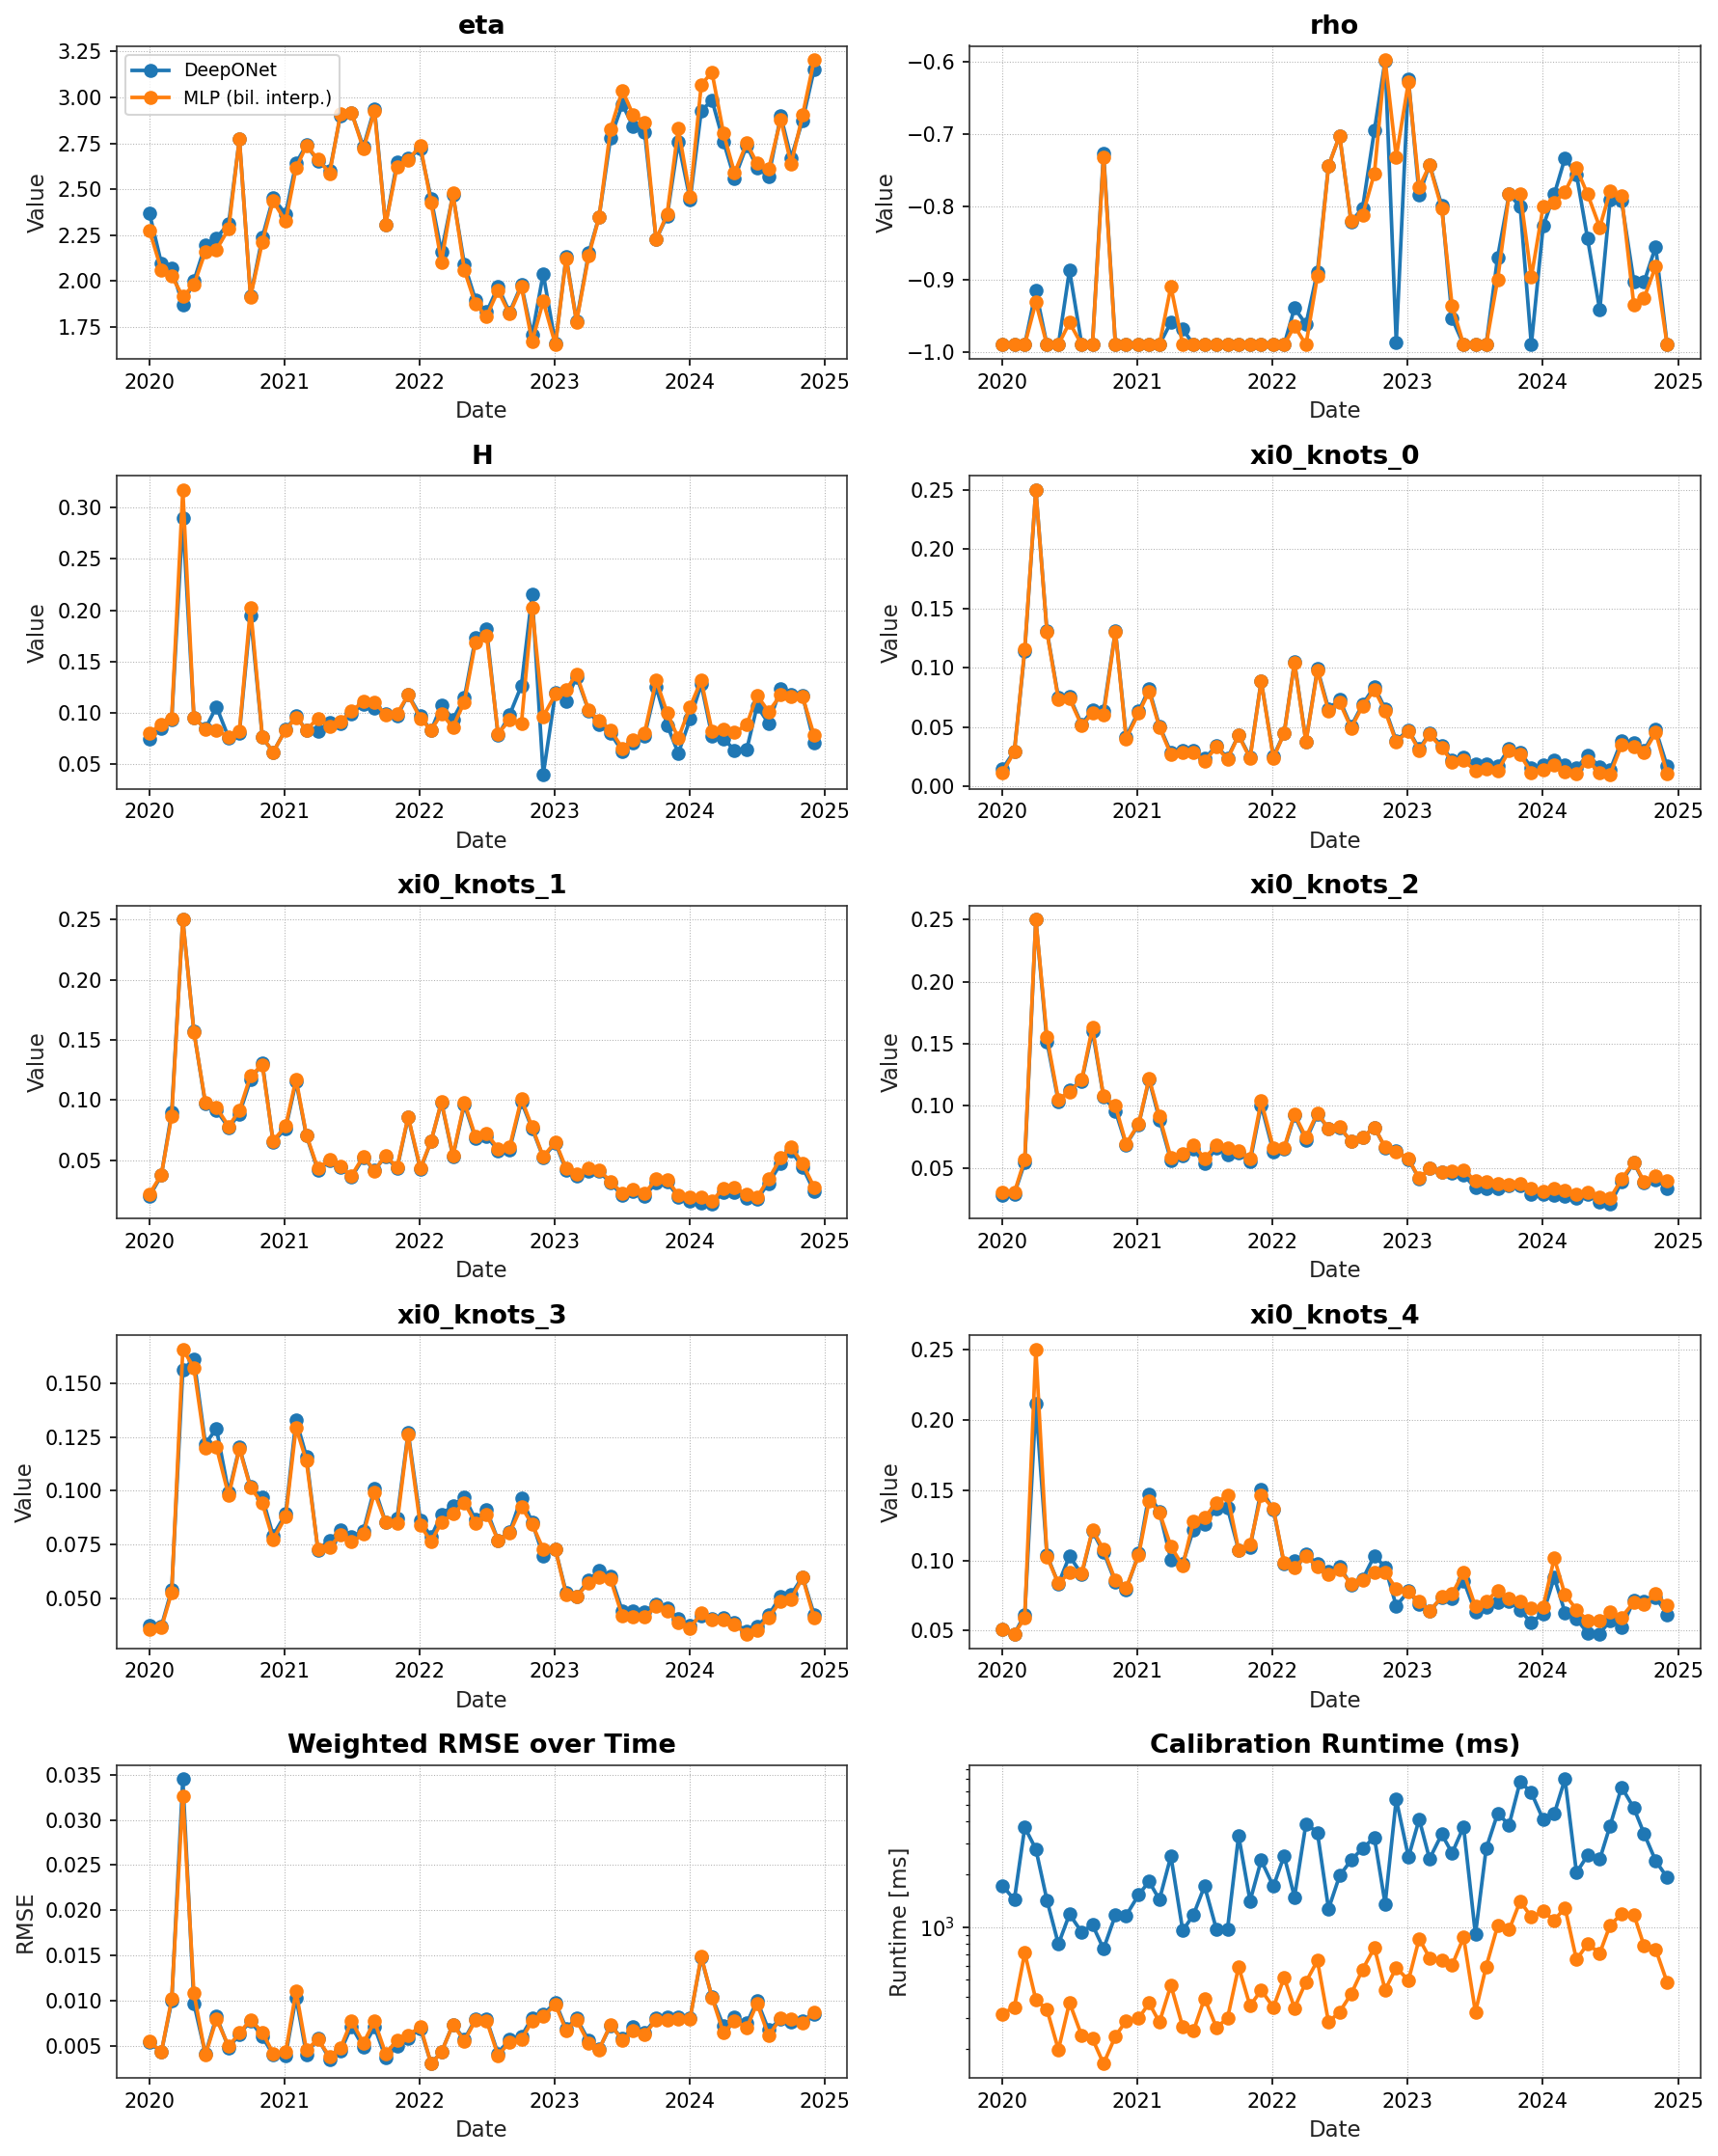

In [4]:
save_path=f"C:/Users/Nils/nn_stochvol_calibrations/real_calibration/plots/{vol}"

if vol == "heston":
    plot_param_grid([deeponet_res, mlp_res, analytic_res],["DeepONet","MLP (bil. interp.)","analytic"], PARAM_NAMES=y.param_names, out_dir=save_path)
else:
    plot_param_grid([deeponet_res, mlp_res],["DeepONet","MLP (bil. interp.)"], PARAM_NAMES=y.param_names, out_dir=save_path)

## Validation of some results

In [6]:
len(deeponet_res)

60

RMSE:  0.015262379


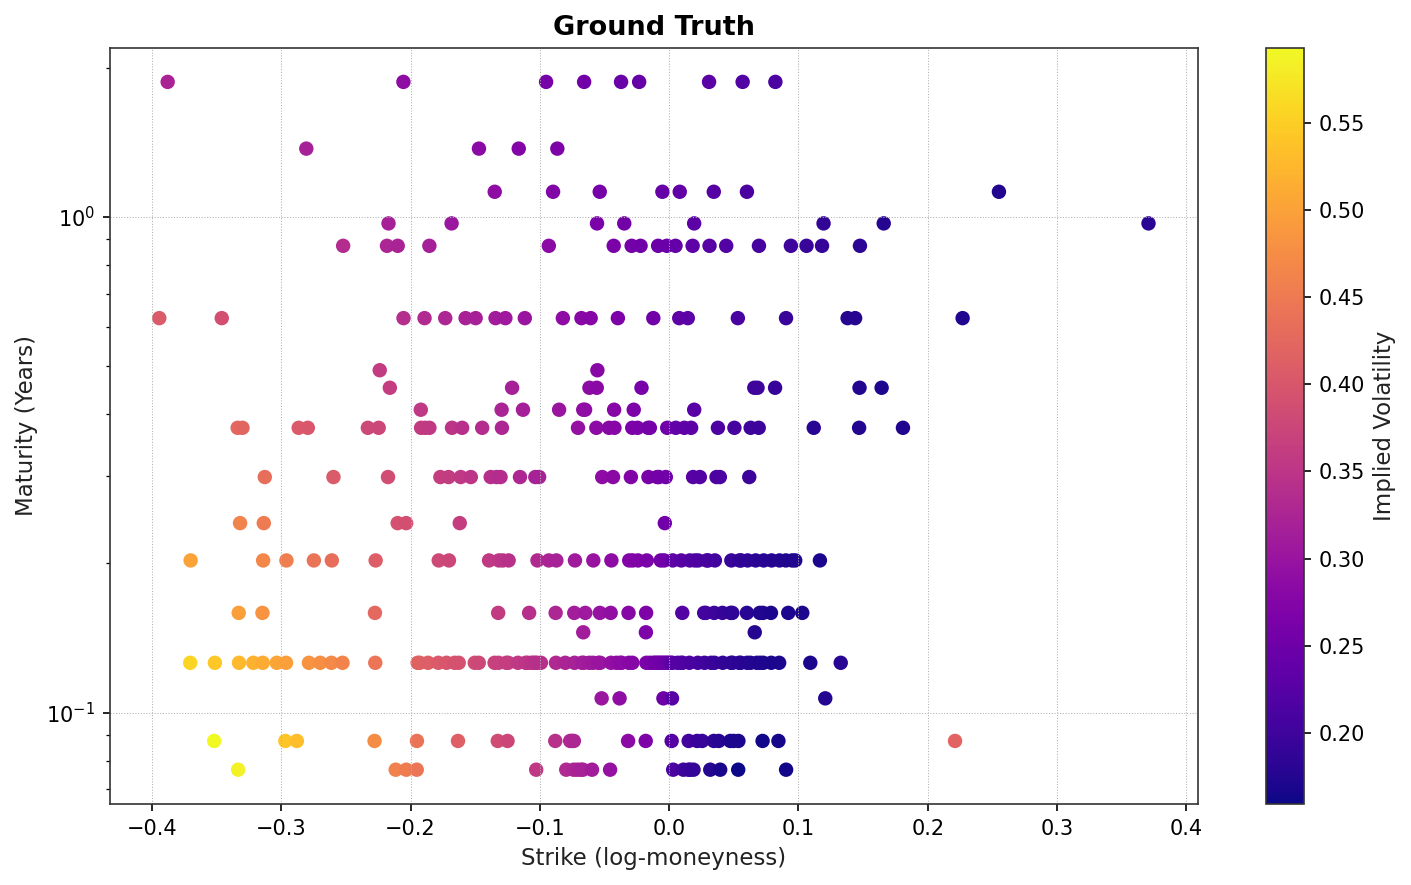

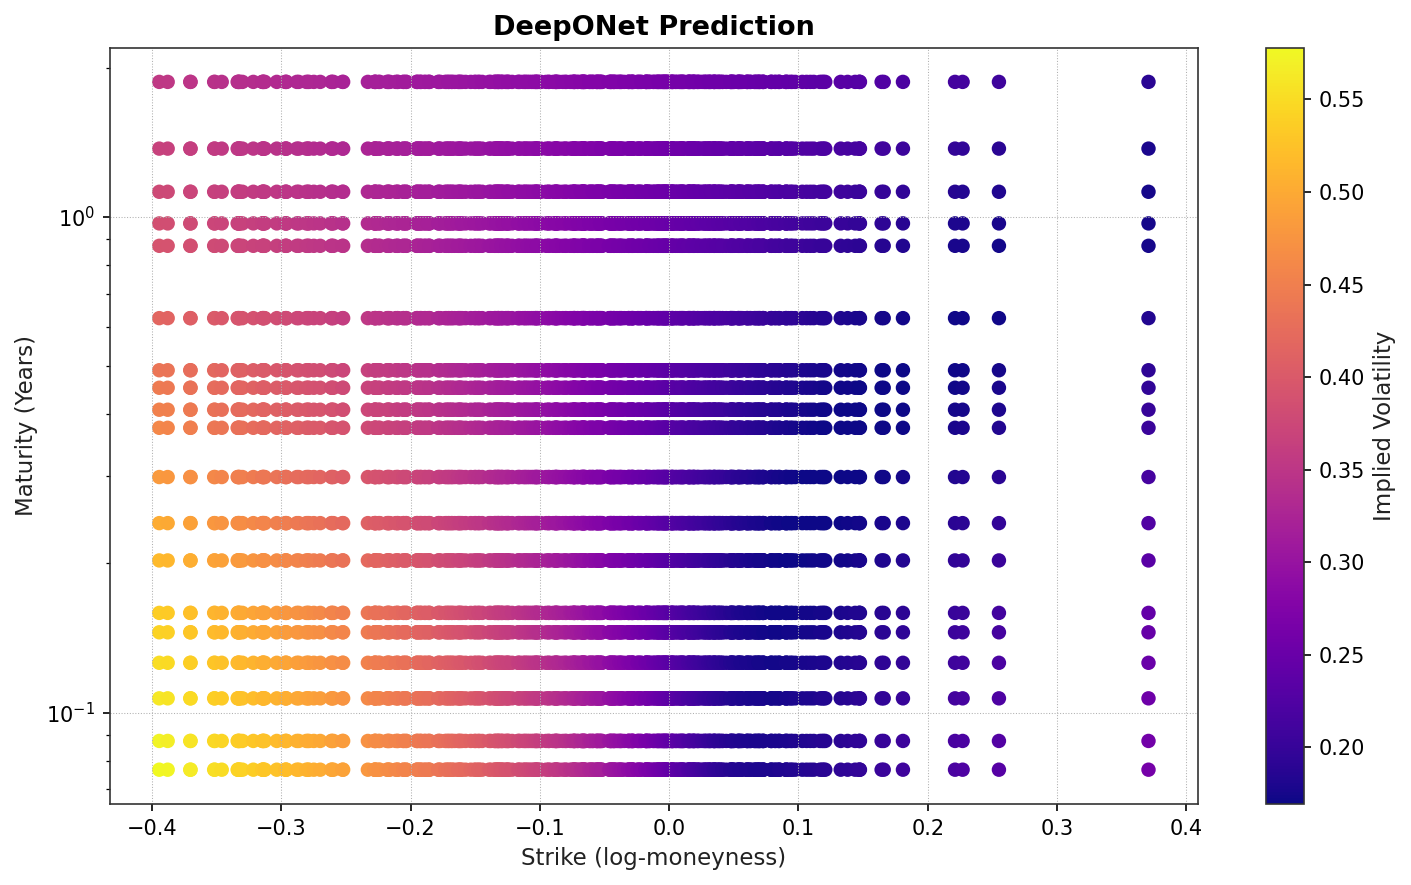

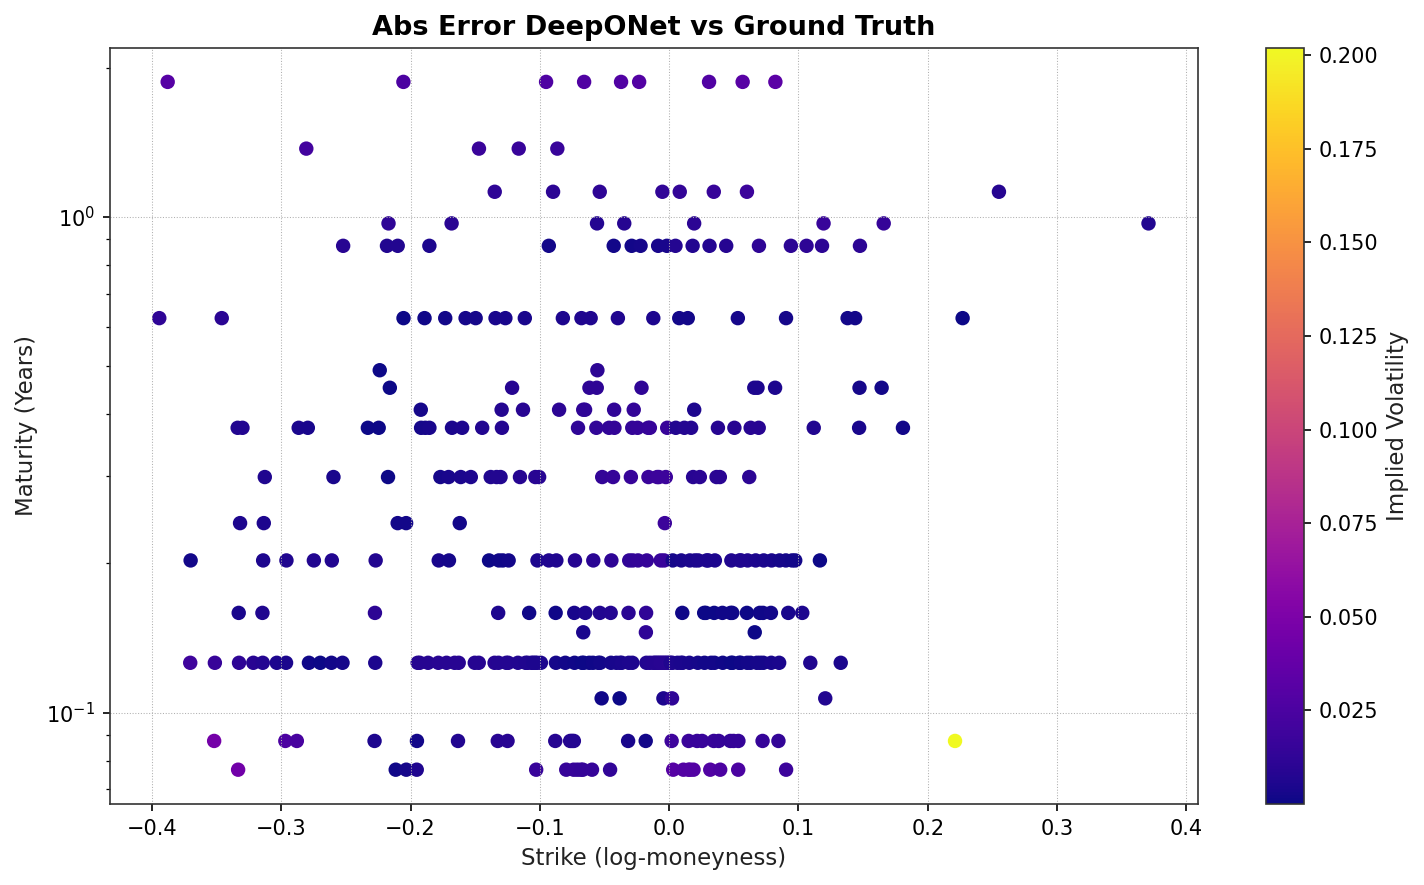

In [6]:
j = 13

p = deeponet_res[j]["theta_hat"]
params = {n: p[i] for i, n in enumerate(x.param_names)}
k = x.predict_surface(params, grid=surfaces[j]["grid"]).detach().numpy()
print("RMSE: ",np.sqrt(np.nanmean((k-surfaces[j]["iv_surface"])**2)))
plot_iv_surface_scatter(surfaces[j]["iv_surface"],surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Ground Truth")
plot_iv_surface_scatter(k,surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="DeepONet Prediction")
plot_iv_surface_scatter(np.abs(k-surfaces[j]["iv_surface"]),surfaces[j]["grid"]["strikes"],np.exp(surfaces[j]["grid"]["maturities"]), title="Abs Error DeepONet vs Ground Truth")